In [1]:
TRAIN_DIR = "/kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train"
TEST_DIR = "/kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Test"

BALANCED_TRAIN_DIR = "/kaggle/working/balanced_train"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [2]:
import os
import shutil
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
    save_img
)

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def get_valid_images(folder):
    valid_files = []

    for f in os.listdir(folder):
        path = os.path.join(folder, f)

        if not os.path.isfile(path):
            continue

        if not f.lower().endswith(VALID_EXTENSIONS):
            continue

        try:
            with Image.open(path) as img:
                img.verify()
            valid_files.append(f)
        except Exception:
            print(f"Skipping invalid image: {path}")

    return valid_files


if os.path.exists(BALANCED_TRAIN_DIR):
    shutil.rmtree(BALANCED_TRAIN_DIR)

os.makedirs(BALANCED_TRAIN_DIR, exist_ok=True)

# count training images
train_class_counts = {}

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)

    if os.path.isdir(cls_path):
        valid_images = get_valid_images(cls_path)
        train_class_counts[cls] = len(valid_images)

print("Original training distribution:")
print(train_class_counts)

target_count = max(train_class_counts.values())
print("Target count:", target_count)

augmentor = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)

    if not os.path.isdir(cls_path):
        continue

    images = get_valid_images(cls_path)

    if len(images) == 0:
        print(f"Skipping empty class: {cls}")
        continue

    output_cls = os.path.join(BALANCED_TRAIN_DIR, cls)
    os.makedirs(output_cls, exist_ok=True)

    # copy originals
    for img_name in images:
        shutil.copy(
            os.path.join(cls_path, img_name),
            os.path.join(output_cls, img_name)
        )

    current_count = len(images)

    if current_count < target_count:
        needed = target_count - current_count
        idx = 0

        while needed > 0:
            img_name = images[idx % current_count]
            img_path = os.path.join(cls_path, img_name)

            try:
                img = load_img(img_path, target_size=IMG_SIZE)
                x = img_to_array(img)
                x = np.expand_dims(x, axis=0)

                aug_iter = augmentor.flow(x, batch_size=1)
                aug_img = next(aug_iter)[0].astype("uint8")

                new_name = f"aug_{needed}_{img_name}"

                save_img(
                    os.path.join(output_cls, new_name),
                    aug_img
                )

                needed -= 1

            except Exception:
                print(f"Failed to augment: {img_path}")

            idx += 1

balanced_counts = {}

for cls in os.listdir(BALANCED_TRAIN_DIR):
    cls_path = os.path.join(BALANCED_TRAIN_DIR, cls)

    if os.path.isdir(cls_path):
        balanced_counts[cls] = len(os.listdir(cls_path))

print("\nBalanced training distribution:")
print(balanced_counts)

2026-05-09 15:38:20.263027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778341100.467191      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778341100.527396      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778341101.002204      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778341101.002241      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778341101.002244      57 computation_placer.cc:177] computation placer alr

Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027770.jpg
Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0027151.jpg
Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0024626.jpg
Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0028449.jpg
Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0025777.jpg
Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmented benign keratosis/ISIC_0026867.jpg
Skipping invalid image: /kaggle/input/datasets/sujentamang/skin-cancer/Skin Cancer Classification/Train/pigmente

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_generator = train_datagen.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_generator.num_classes
print("Number of classes:", num_classes)
print("Class mapping:", train_generator.class_indices)

Found 3276 images belonging to 9 classes.
Found 819 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Number of classes: 9
Class mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    baseline_model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),

        Dense(num_classes, activation='softmax')
    ])

    baseline_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

baseline_model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1778341175.616651      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778341175.622710      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,409 (85.02 MB)

 Trainable params: 22,286,409 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1778341180.192108     151 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778341180.192792     149 cuda_dnn.cc:529] Loaded cuDNN version 91002


103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.1555 - loss: 2.2039INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
103/103 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.1559 - loss: 2.2026 - val_accuracy: 0.2613 - val_loss: 2.0406
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.3135 - loss: 1.7718 - val_accuracy: 0.3602 - val_loss: 1.9170
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.4489 - loss: 1.4261 - val_accuracy: 0.3443 - val_loss: 1.8297
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.5235 - loss: 1.2881 - val_accuracy: 0.3651 - val_loss: 1.8317
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.5765 - loss: 1.1461 - val_accuracy: 0.3651 - val_loss: 2.1579


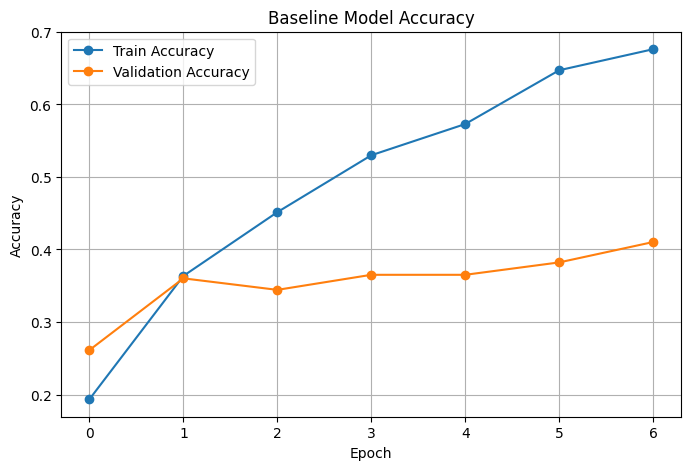

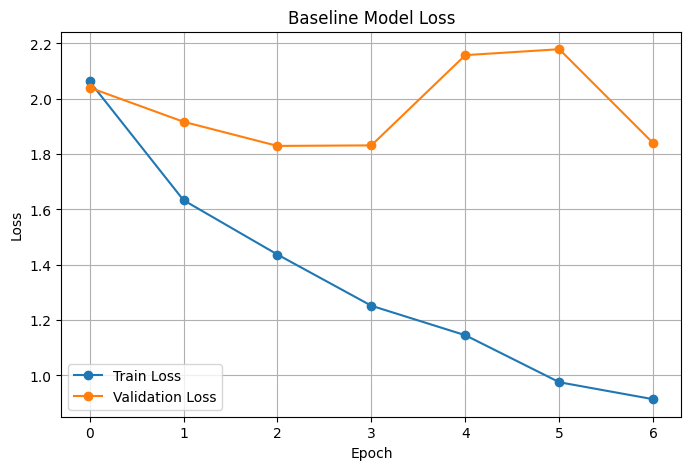

In [6]:
import matplotlib.pyplot as plt

# accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
test_loss, test_acc = baseline_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3421 - loss: 2.5099
Test Loss: 2.51717472076416
Test Accuracy: 0.31355932354927063


In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred_probs = baseline_model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

cm = confusion_matrix(true_classes, pred_classes)
print(cm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
                            precision    recall  f1-score   support

         actinic keratosis       0.36      0.31      0.33        16
      basal cell carcinoma       0.33      0.56      0.42        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.22      0.25      0.24        16
                     nevus       0.43      0.38      0.40        16
pigmented benign keratosis       0.31      0.69      0.43        16
      seborrheic keratosis       0.33      0.33      0.33         3
   squamous cell carcinoma       0.20      0.06      0.10        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.31       118
                 macro avg       0.24      0.29      0.25       118
              weighted avg       0.26      0.31      0.27       118

[[ 5  4  0  2  0  4  0  1  0]
 [ 2  9  0  1  0  1  1  2  0]
 [ 6  5  0  3  1 

In [9]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(true_classes, pred_classes)
print("Baseline Test Accuracy:", acc)

Baseline Test Accuracy: 0.3135593220338983


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

num_classes = train_generator.num_classes

deeper_model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    Dropout(0.4),

    Dense(num_classes, activation="softmax")
])

deeper_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,241 (1.23 MB)

 Trainable params: 322,793 (1.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

start = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

print("Training time:", time.time() - start)

Epoch 1/30


I0000 00:00:1778341490.698020     149 service.cc:152] XLA service 0x3c8aa8b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778341490.698062     149 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778341490.698066     149 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-05-09 15:44:56.720586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:44:56.875693: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:45:00.525092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has

  1/103 ━━━━━━━━━━━━━━━━━━━━ 45:10 27s/step - accuracy: 0.0625 - loss: 2.6084

I0000 00:00:1778341513.919386     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 95/103 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.2813 - loss: 1.9601

2026-05-09 15:45:31.425257: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:45:31.575334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:45:33.403595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:45:33.692971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


103/103 ━━━━━━━━━━━━━━━━━━━━ 69s 414ms/step - accuracy: 0.2860 - loss: 1.9454 - val_accuracy: 0.1111 - val_loss: 2.6234 - learning_rate: 0.0010
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 207ms/step - accuracy: 0.4366 - loss: 1.5423 - val_accuracy: 0.1111 - val_loss: 3.7442 - learning_rate: 0.0010
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.4402 - loss: 1.4927 - val_accuracy: 0.1148 - val_loss: 3.0526 - learning_rate: 0.0010
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4859 - loss: 1.3844
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 215ms/step - accuracy: 0.4861 - loss: 1.3840 - val_accuracy: 0.1770 - val_loss: 2.8967 - learning_rate: 0.0010
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.5946 - loss: 1.1699 - val_accuracy: 0.2320 - val_loss: 2.8364 - learning_rate: 5.0000e-04
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 210ms/step - accuracy: 0.6114 - los

In [16]:
test_loss_deeper, test_acc_deeper = deeper_model.evaluate(test_generator)

print(f"Deeper Test Loss: {test_loss_deeper:.4f}")
print(f"Deeper Test Accuracy: {test_acc_deeper:.4f}")
print(f"Deeper Test Accuracy: {test_acc_deeper * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2103 - loss: 3.2465
Deeper Test Loss: 3.0877
Deeper Test Accuracy: 0.2627
Deeper Test Accuracy: 26.27%


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)

num_classes = train_generator.num_classes

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def res_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x

inputs = Input(shape=(224, 224, 3))

x = layers.Rescaling(1.0 / 255)(inputs)
x = data_augmentation(x)

x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.MaxPooling2D()(x)

x = res_block(x, 32)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.1)(x)

x = res_block(x, 64)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.1)(x)

x = res_block(x, 128)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.15)(x)

x = res_block(x, 256)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

deeper_model = Model(inputs, outputs)

deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model.summary()

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 224, 224,  │        864 │ sequential_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 112, 112,  │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 112, 112,  │      9,216 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 112, 112,  │      9,216 │ activation_10[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 112, 112,  │          0 │ add_4[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 56, 56,    │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_11… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 56, 56,    │     18,432 │ dropout_8[0][0] 

 Total params: 1,263,337 (4.82 MB)

 Trainable params: 1,260,457 (4.81 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

start = time.time()

history_deeper = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

print("Training time:", time.time() - start)

Epoch 1/30


E0000 00:00:1778342122.896114      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/dropout_8_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


103/103 ━━━━━━━━━━━━━━━━━━━━ 37s 266ms/step - accuracy: 0.3496 - loss: 1.7723 - val_accuracy: 0.1111 - val_loss: 2.9100 - learning_rate: 3.0000e-04
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 248ms/step - accuracy: 0.5021 - loss: 1.3915 - val_accuracy: 0.1111 - val_loss: 4.2791 - learning_rate: 3.0000e-04
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 241ms/step - accuracy: 0.4974 - loss: 1.3432 - val_accuracy: 0.1111 - val_loss: 4.1610 - learning_rate: 3.0000e-04
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5130 - loss: 1.3055
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.5131 - loss: 1.3053 - val_accuracy: 0.1111 - val_loss: 3.9511 - learning_rate: 3.0000e-04
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 25s 246ms/step - accuracy: 0.5956 - loss: 1.1245 - val_accuracy: 0.1111 - val_loss: 4.5106 - learning_rate: 1.5000e-04
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accura

In [21]:
test_loss_deeper, test_acc_deeper = deeper_model.evaluate(test_generator)

print(f"Deeper Test Loss: {test_loss_deeper:.4f}")
print(f"Deeper Test Accuracy: {test_acc_deeper:.4f}")
print(f"Deeper Test Accuracy: {test_acc_deeper * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2376 - loss: 3.0610
Deeper Test Loss: 3.0007
Deeper Test Accuracy: 0.1356
Deeper Test Accuracy: 13.56%


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_SIZE = (224, 224)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# Freeze base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.optimizers import Adam

def create_deeper_cnn(input_shape=(224,224,3), num_classes=9):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.3),

        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

deeper_cnn = create_deeper_cnn()
deeper_cnn.compile(optimizer=Adam(learning_rate=1e-3),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])
deeper_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,137 (1.24 MB)

 Trainable params: 323,241 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history_deeper = deeper_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 40s 296ms/step - accuracy: 0.3159 - loss: 1.8889 - val_accuracy: 0.1123 - val_loss: 3.2156 - learning_rate: 0.0010
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.4689 - loss: 1.4910 - val_accuracy: 0.1111 - val_loss: 3.9429 - learning_rate: 0.0010
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.5372 - loss: 1.2891 - val_accuracy: 0.1270 - val_loss: 3.5379 - learning_rate: 0.0010
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.5422 - loss: 1.2461
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.5422 - loss: 1.2460 - val_accuracy: 0.1490 - val_loss: 3.3122 - learning_rate: 0.0010
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step - accuracy: 0.5898 - loss: 1.1037 - val_accuracy: 0.2821 - val_loss: 2.1198 - learning_rate: 5.0000e-04
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0

In [31]:
test_loss, test_acc = deeper_cnn.evaluate(test_generator)
print(f"Deeper CNN Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3327 - loss: 2.2830
Deeper CNN Test Accuracy: 0.2458


In [32]:
from tensorflow.keras.optimizers import SGD

deeper_sgd = create_deeper_cnn()
deeper_sgd.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_sgd = deeper_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 38s 288ms/step - accuracy: 0.2967 - loss: 1.8959 - val_accuracy: 0.1111 - val_loss: 2.6545 - learning_rate: 0.0100
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 230ms/step - accuracy: 0.4292 - loss: 1.5209 - val_accuracy: 0.1197 - val_loss: 2.7786 - learning_rate: 0.0100
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 215ms/step - accuracy: 0.4657 - loss: 1.4629 - val_accuracy: 0.1819 - val_loss: 2.6787 - learning_rate: 0.0100
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 217ms/step - accuracy: 0.4838 - loss: 1.4095 - val_accuracy: 0.2527 - val_loss: 2.1779 - learning_rate: 0.0100
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 24s 227ms/step - accuracy: 0.4992 - loss: 1.3778 - val_accuracy: 0.3101 - val_loss: 1.8585 - learning_rate: 0.0100
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.5019 - loss: 1.3337 - val_accuracy: 0.2784 - val_loss: 2.3314 - learning_rate: 0.0100
Epoch 7/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step - accuracy: 0.5

In [33]:
# After training deeper_sgd
test_loss_sgd, test_acc_sgd = deeper_sgd.evaluate(test_generator)
print(f"SGD Model - Test Loss: {test_loss_sgd:.4f}")
print(f"SGD Model - Test Accuracy: {test_acc_sgd:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.2897 - loss: 2.3492
SGD Model - Test Loss: 2.1752
SGD Model - Test Accuracy: 0.3051


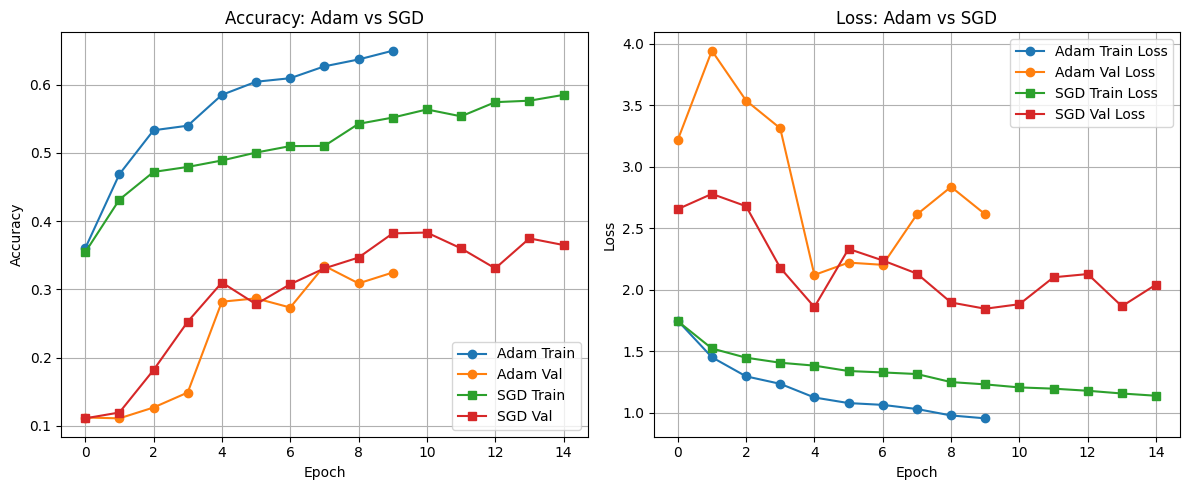

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['accuracy'], label='Adam Train', marker='o')
plt.plot(history_deeper.history['val_accuracy'], label='Adam Val', marker='o')
plt.plot(history_sgd.history['accuracy'], label='SGD Train', marker='s')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val', marker='s')
plt.title('Accuracy: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['loss'], label='Adam Train Loss', marker='o')
plt.plot(history_deeper.history['val_loss'], label='Adam Val Loss', marker='o')
plt.plot(history_sgd.history['loss'], label='SGD Train Loss', marker='s')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss', marker='s')
plt.title('Loss: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [38]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================
# STEP 1: Create NEW generators with correct preprocessing
# ============================================
# IMPORTANT: Do NOT use rescale=1./255 here because preprocess_input will handle it.
train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

val_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Use the same directories as before
train_generator_tl = train_datagen_tl.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator_tl = val_datagen_tl.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator_tl = test_datagen_tl.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ============================================
# STEP 2: Build transfer learning model
# ============================================
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze base for feature extraction

inputs = tf.keras.Input(shape=(224,224,3))
x = preprocess_input(inputs)  # ensure input is correctly scaled
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================
# STEP 3: Train only the new head (feature extraction)
# ============================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("Training feature extraction phase...")
history_fe = model.fit(
    train_generator_tl,
    validation_data=val_generator_tl,
    epochs=15,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# ============================================
# STEP 4: Fine-tune the top layers of the base model
# ============================================
# Unfreeze the last 30 layers of MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning phase...")
history_ft = model.fit(
    train_generator_tl,
    validation_data=val_generator_tl,
    epochs=15,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# ============================================
# STEP 5: Evaluate on test set
# ============================================
test_loss, test_acc = model.evaluate(test_generator_tl)
print(f"\nTransfer Learning Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Found 3276 images belonging to 9 classes.
Found 819 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Training feature extraction phase...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 43s 319ms/step - accuracy: 0.2379 - loss: 2.4963 - val_accuracy: 0.1123 - val_loss: 2.2610 - learning_rate: 0.0010
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - accuracy: 0.3784 - loss: 1.8720 - val_accuracy: 0.1368 - val_loss: 2.2206 - learning_rate: 0.0010
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.4371 - loss: 1.6511 - val_accuracy: 0.1941 - val_loss: 2.0990 - learning_rate: 0.0010
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.4615 - loss: 1.5740 - val_accuracy: 0.2759 - val_loss: 2.0044 - learning_rate: 0.0010
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.4756 - loss: 1.5017 - val_accuracy: 0.3626 - val_loss: 1.9126 - learning_rate: 0.0010
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 195ms/step - accuracy: 0.4984 - loss: 1.4492 - val_accuracy: 0.3370 - val_loss: 1.8960 - learning_rate: 0.0010
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.4

In [39]:
print(f"Training samples: {train_generator_tl.samples}")
print(f"Validation samples: {val_generator_tl.samples}")
print(f"Test samples: {test_generator_tl.samples}")

Training samples: 3276
Validation samples: 819
Test samples: 118


In [40]:
# Check class indices consistency
print("Train class indices:", train_generator_tl.class_indices)
print("Test class indices:", test_generator_tl.class_indices)
assert train_generator_tl.class_indices == test_generator_tl.class_indices, "Class mismatch!"

Train class indices: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
Test class indices: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [41]:
import numpy as np
from sklearn.metrics import classification_report

pred_probs = model.predict(test_generator_tl)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator_tl.classes

print("Unique predicted classes:", np.unique(pred_classes))
print("Class distribution in predictions:", np.bincount(pred_classes, minlength=num_classes))
print(classification_report(true_classes, pred_classes, target_names=class_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step 
Unique predicted classes: [5]
Class distribution in predictions: [  0   0   0   0   0 118   0   0   0]
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.00      0.00      0.00        16
pigmented benign keratosis       0.14      1.00      0.24        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.14       118
                 macro avg       0.02      0.11      0.03       118
              weighted avg       0.02    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
print("Train class indices:", train_generator.class_indices)
print("Test class indices:", test_generator.class_indices)

Train class indices: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
Test class indices: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [43]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================
# 1. Data generators – NO preprocessing_function here
# ============================================
train_datagen_aug = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(validation_split=0.2)
test_datagen = ImageDataGenerator()

train_gen = train_datagen_aug.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    BALANCED_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_gen.num_classes
print("Number of classes:", num_classes)
print("Class mapping:", train_gen.class_indices)

# ============================================
# 2. Build model with EfficientNetB0
# ============================================
base_model = EfficientNetB0(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False   # Freeze for feature extraction

inputs = tf.keras.Input(shape=(224,224,3))
x = preprocess_input(inputs)   # Preprocessing applied ONLY here (once)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================
# 3. Phase 1: Train only the new top layers
# ============================================
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("\nPhase 1: Feature extraction (freezing base model)")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# ============================================
# 4. Phase 2: Fine‑tune the top 50 layers of base model
# ============================================
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with a very low learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nPhase 2: Fine‑tuning (unfreezing top 50 layers)")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

# ============================================
# 5. Evaluate on the test set
# ============================================
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Found 3276 images belonging to 9 classes.
Found 819 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Number of classes: 9
Class mapping: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Phase 1: Feature extraction (freezing base model)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


2026-05-09 17:02:59.225220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:02:59.368542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:02:59.724305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:02:59.866205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:03:00.653473: E external/local_xla/xla/stream_

 12/103 ━━━━━━━━━━━━━━━━━━━━ 37s 413ms/step - accuracy: 0.1425 - loss: 3.2148

...

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.2997 - loss: 2.4921

2026-05-09 17:04:19.745476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:04:19.886535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:04:20.219067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:04:20.360519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:04:21.149401: E external/local_xla/xla/stream_

103/103 ━━━━━━━━━━━━━━━━━━━━ 102s 752ms/step - accuracy: 0.3005 - loss: 2.4882 - val_accuracy: 0.2589 - val_loss: 2.0335 - learning_rate: 0.0010
Epoch 2/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 50s 481ms/step - accuracy: 0.5275 - loss: 1.4754 - val_accuracy: 0.2772 - val_loss: 2.4442 - learning_rate: 0.0010
Epoch 3/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 49s 478ms/step - accuracy: 0.5560 - loss: 1.3366 - val_accuracy: 0.3150 - val_loss: 2.6037 - learning_rate: 0.0010
Epoch 4/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.5886 - loss: 1.1862
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
103/103 ━━━━━━━━━━━━━━━━━━━━ 48s 473ms/step - accuracy: 0.5887 - loss: 1.1859 - val_accuracy: 0.3101 - val_loss: 2.6956 - learning_rate: 0.0010
Epoch 5/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 48s 471ms/step - accuracy: 0.6273 - loss: 1.0978 - val_accuracy: 0.3370 - val_loss: 2.5524 - learning_rate: 5.0000e-04
Epoch 6/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 49s 471ms/step - accuracy: 0.6426 - lo

2026-05-09 17:17:43.986694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:17:44.128654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:17:44.470283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:17:44.611617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 17:17:45.407632: E external/local_xla/xla/stream_

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.3507 - loss: 2.0480

Test Loss: 2.0753
Test Accuracy: 0.3220 (32.20%)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step 

Classification Report for baseline_model
                            precision    recall  f1-score   support

         actinic keratosis       0.36      0.31      0.33        16
      basal cell carcinoma       0.33      0.56      0.42        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.22      0.25      0.24        16
                     nevus       0.43      0.38      0.40        16
pigmented benign keratosis       0.31      0.69      0.43        16
      seborrheic keratosis       0.33      0.33      0.33         3
   squamous cell carcinoma       0.20      0.06      0.10        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.31       118
                 macro avg       0.24      0.29      0.25       118
              weighted avg  

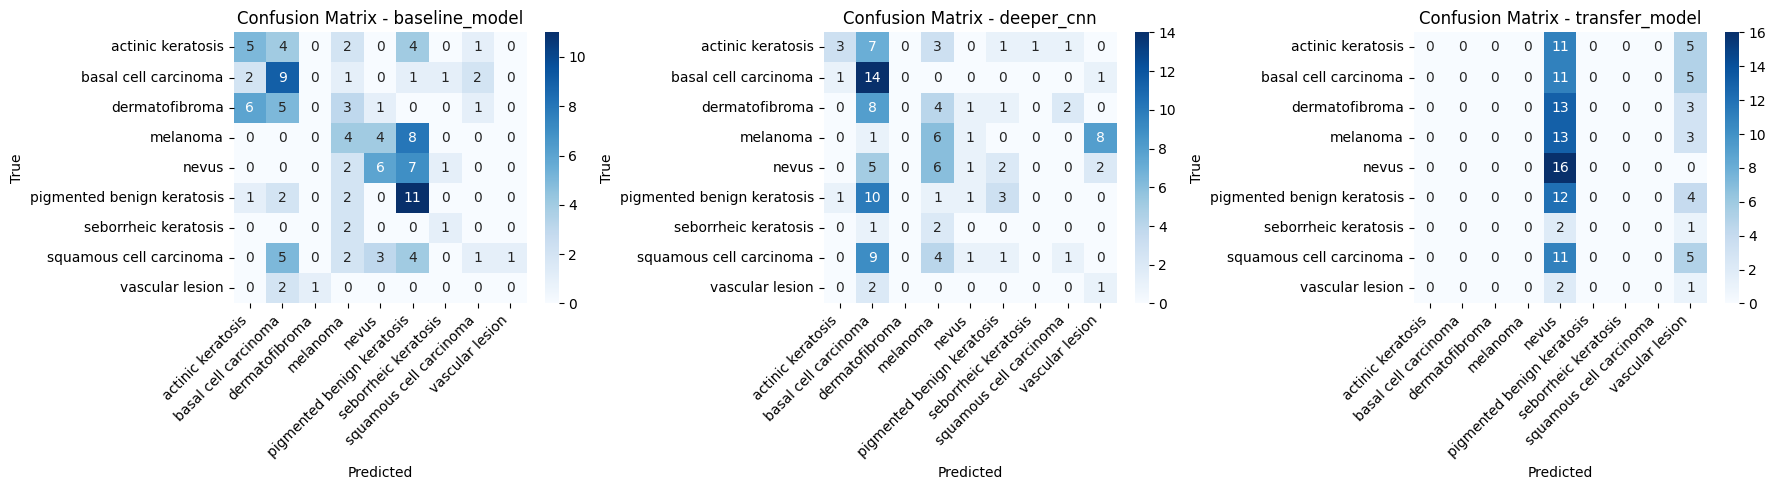

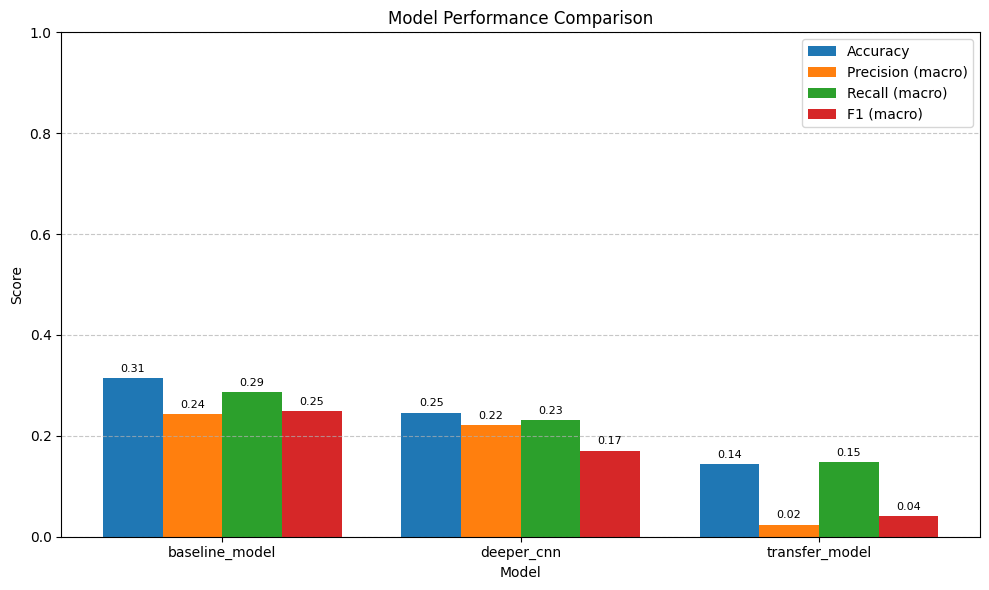

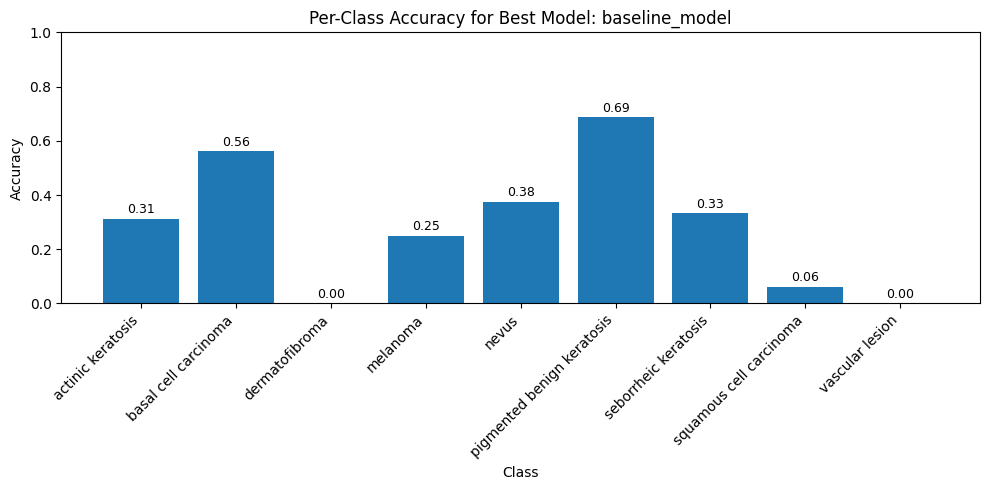

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Ensure test_generator is defined (should be from earlier)
# test_generator = ... (with shuffle=False)

# Dictionary to store predictions and true labels for each model
model_predictions = {}
model_names = ['baseline_model', 'deeper_cnn', 'transfer_model']
actual_models = [baseline_model, deeper_cnn, transfer_model]  # use your actual variable names

for name, model in zip(model_names, actual_models):
    # Predict probabilities
    pred_probs = model.predict(test_generator)
    pred_classes = np.argmax(pred_probs, axis=1)
    true_classes = test_generator.classes
    model_predictions[name] = (true_classes, pred_classes)

# Get class names
class_names = list(test_generator.class_indices.keys())

# ============================================
# 1. Print classification reports
# ============================================
for name, (true, pred) in model_predictions.items():
    print(f"\n{'='*60}")
    print(f"Classification Report for {name}")
    print('='*60)
    print(classification_report(true, pred, target_names=class_names, zero_division=0))

# ============================================
# 2. Compute aggregate metrics for comparison
# ============================================
metrics = {'Model': [], 'Accuracy': [], 'Precision (macro)': [], 'Recall (macro)': [], 'F1 (macro)': []}

for name, (true, pred) in model_predictions.items():
    acc = accuracy_score(true, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(true, pred, average='macro', zero_division=0)
    metrics['Model'].append(name)
    metrics['Accuracy'].append(acc)
    metrics['Precision (macro)'].append(prec)
    metrics['Recall (macro)'].append(rec)
    metrics['F1 (macro)'].append(f1)

# Display metrics table
import pandas as pd
df_metrics = pd.DataFrame(metrics)
print("\n\nSummary Metrics Comparison:")
print(df_metrics.to_string(index=False))

# ============================================
# 3. Plot confusion matrices as heatmaps
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (true, pred)) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ============================================
# 4. Bar chart comparison of metrics
# ============================================
x = np.arange(len(df_metrics['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - 1.5*width, df_metrics['Accuracy'], width, label='Accuracy')
bars2 = ax.bar(x - 0.5*width, df_metrics['Precision (macro)'], width, label='Precision (macro)')
bars3 = ax.bar(x + 0.5*width, df_metrics['Recall (macro)'], width, label='Recall (macro)')
bars4 = ax.bar(x + 1.5*width, df_metrics['F1 (macro)'], width, label='F1 (macro)')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Model'])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ============================================
# 5. (Optional) Plot accuracy per class for best model
# ============================================
# Choose best model based on accuracy
best_model_name = df_metrics.loc[df_metrics['Accuracy'].idxmax(), 'Model']
true_best, pred_best = model_predictions[best_model_name]

# Per-class accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_best, pred_best)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(class_names, per_class_acc)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title(f'Per-Class Accuracy for Best Model: {best_model_name}')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, acc in enumerate(per_class_acc):
    plt.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

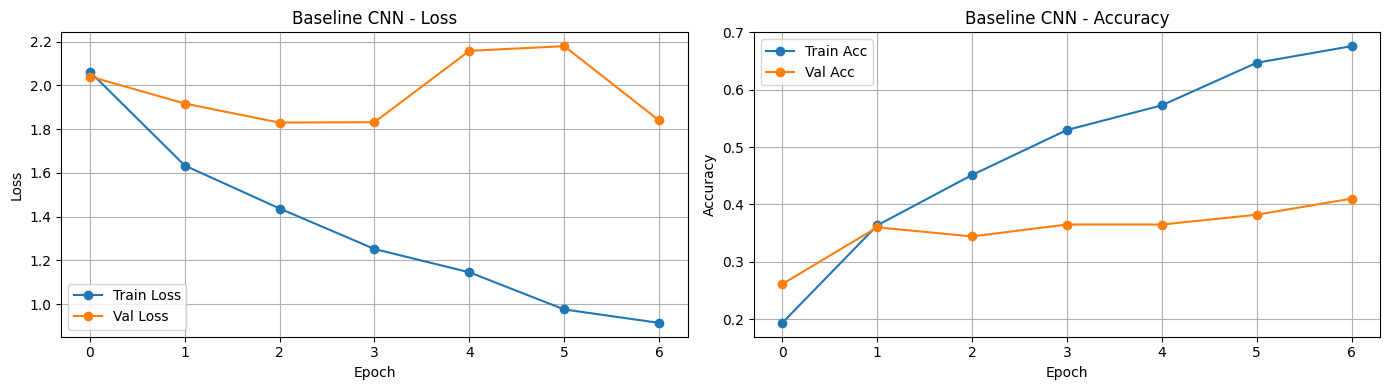

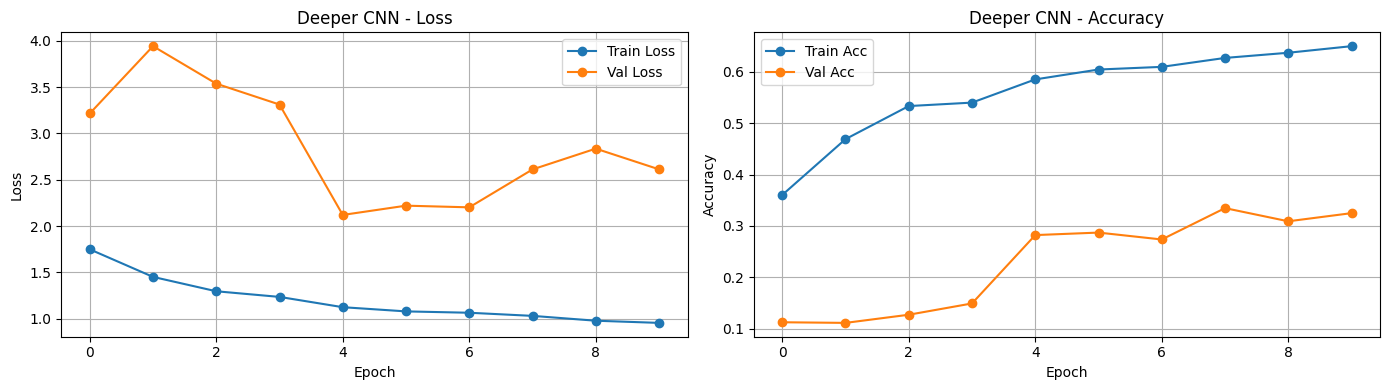

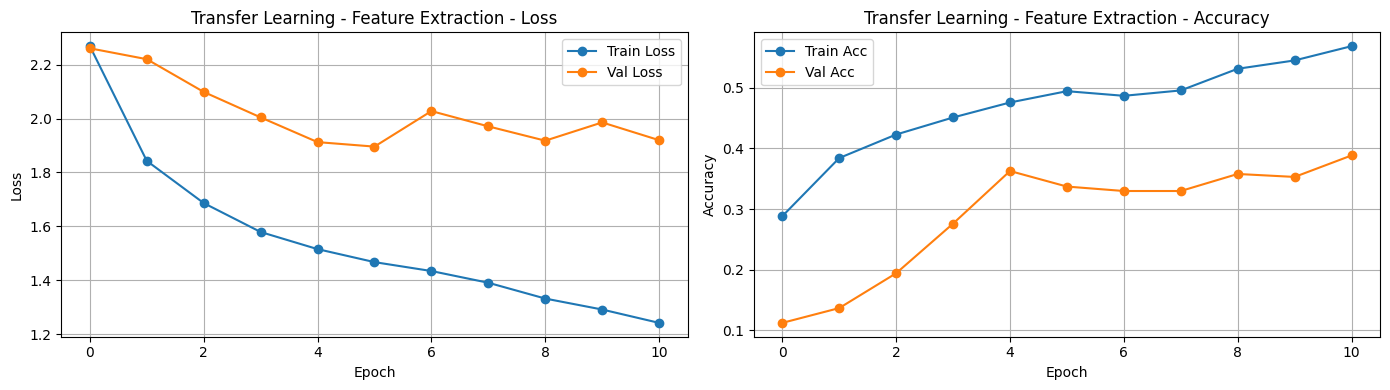

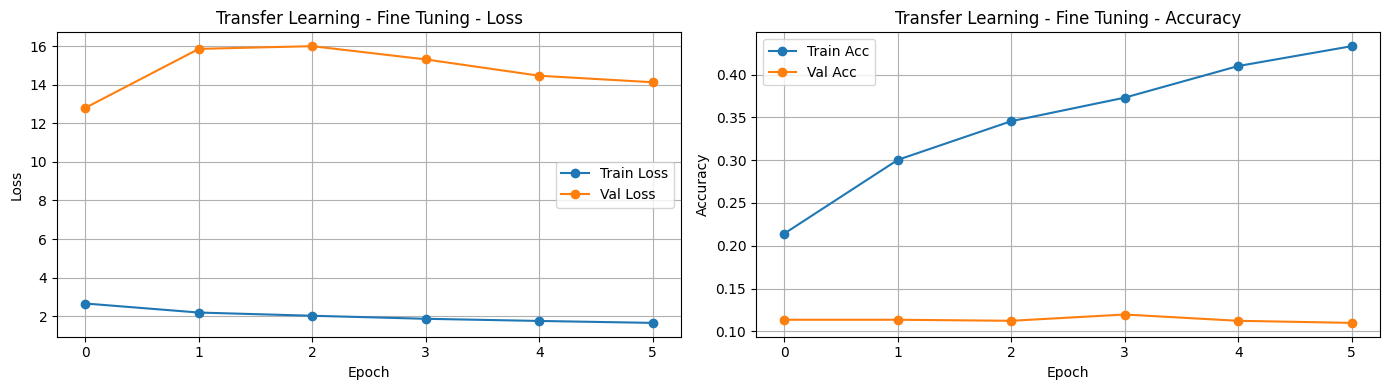

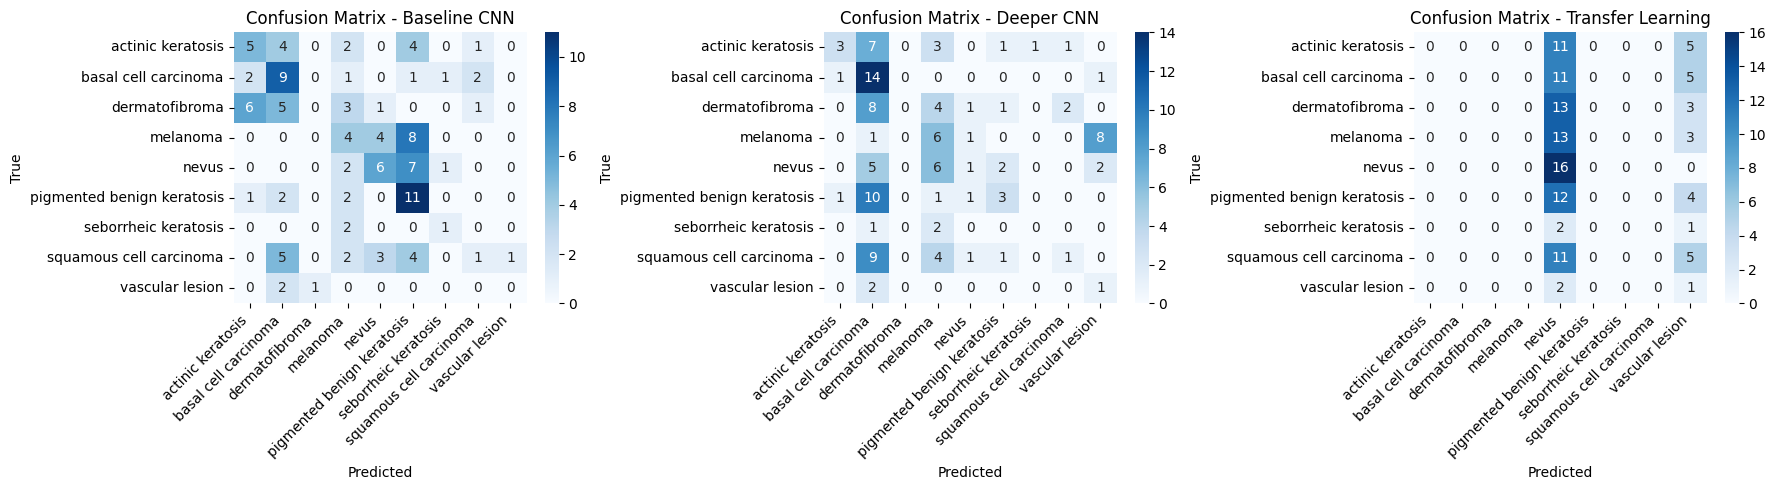

Performance Metrics Table:
            Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
     Baseline CNN  0.313559           0.243210        0.287037    0.249686
       Deeper CNN  0.245763           0.220524        0.231481    0.170396
Transfer Learning  0.144068           0.023651        0.148148    0.040637


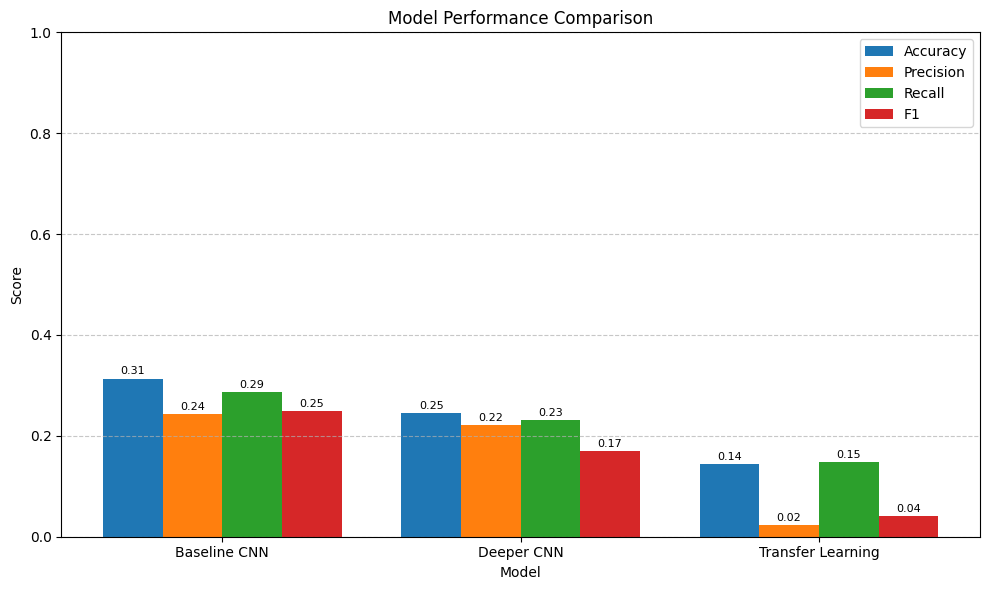

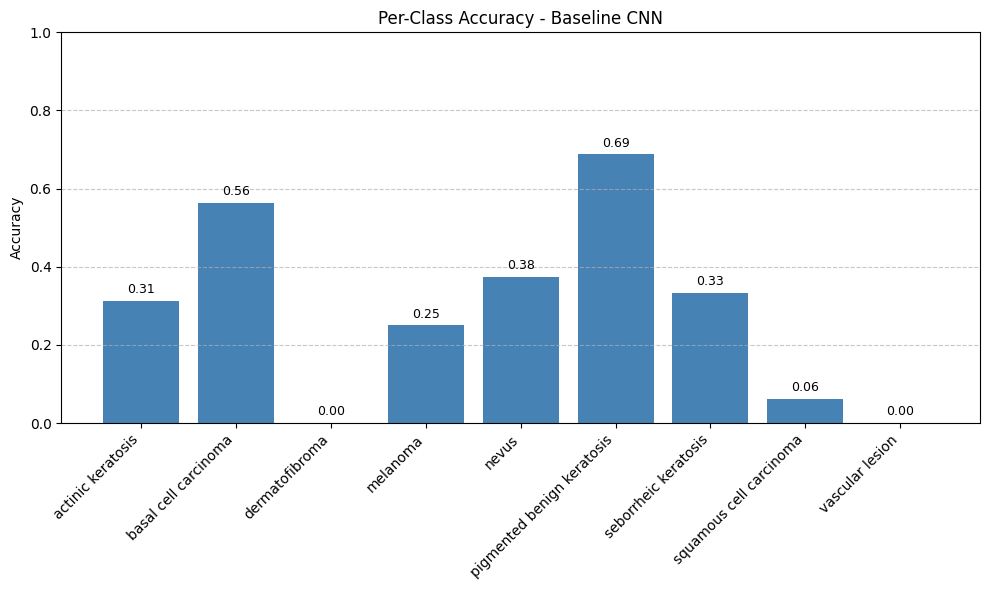

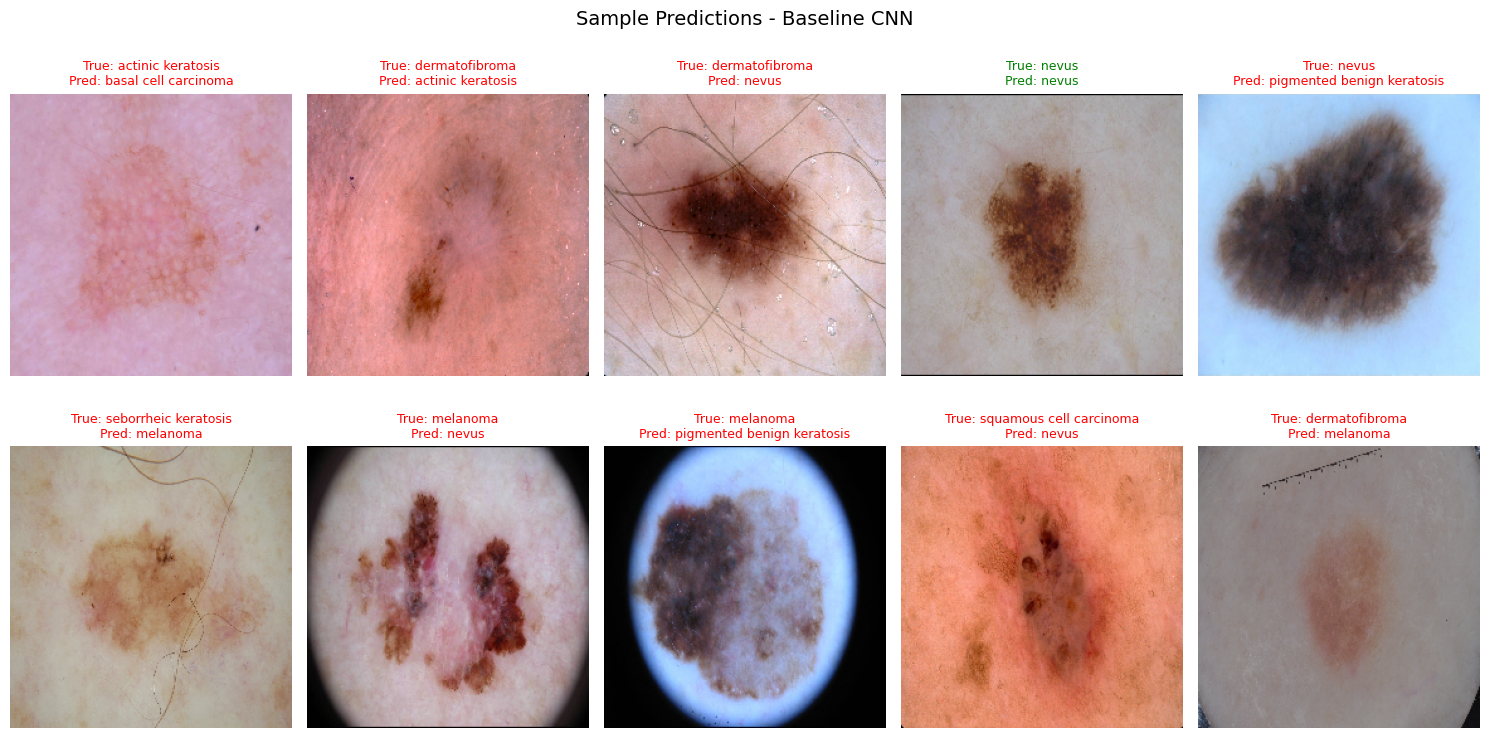

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# ============================================
# Helper: Plot training history (loss & accuracy)
# ============================================
def plot_training_history(history, title, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', marker='o')
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='o')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='o')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150)
    plt.show()

# Plot for each model (replace with your actual history variable names)
if 'history' in locals():
    plot_training_history(history, 'Baseline CNN')
if 'history_deeper' in locals():
    plot_training_history(history_deeper, 'Deeper CNN')
if 'history_fe' in locals():
    plot_training_history(history_fe, 'Transfer Learning - Feature Extraction')
if 'history_ft' in locals():
    plot_training_history(history_ft, 'Transfer Learning - Fine Tuning')

# ============================================
# 1. Confusion Matrices for all three models
# ============================================
# Ensure test_generator is defined (shuffle=False)
# Compute predictions for each model
models = {
    'Baseline CNN': baseline_model,
    'Deeper CNN': deeper_cnn,
    'Transfer Learning': transfer_model
}

predictions = {}
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

for name, model in models.items():
    probs = model.predict(test_generator, verbose=0)
    preds = np.argmax(probs, axis=1)
    predictions[name] = preds

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# ============================================
# 2. Performance Comparison Bar Chart
# ============================================
metrics_data = []
for name, preds in predictions.items():
    acc = accuracy_score(true_labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(true_labels, preds, average='macro', zero_division=0)
    metrics_data.append([name, acc, prec, rec, f1])

df_metrics = pd.DataFrame(metrics_data, columns=['Model', 'Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)'])
print("Performance Metrics Table:")
print(df_metrics.to_string(index=False))

# Bar chart
x = np.arange(len(df_metrics['Model']))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - 1.5*width, df_metrics['Accuracy'], width, label='Accuracy')
bars2 = ax.bar(x - 0.5*width, df_metrics['Precision (macro)'], width, label='Precision')
bars3 = ax.bar(x + 0.5*width, df_metrics['Recall (macro)'], width, label='Recall')
bars4 = ax.bar(x + 1.5*width, df_metrics['F1 (macro)'], width, label='F1')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Model'])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150)
plt.show()

# ============================================
# 3. Per-Class Accuracy for Best Model
# ============================================
best_model_name = df_metrics.loc[df_metrics['Accuracy'].idxmax(), 'Model']
best_preds = predictions[best_model_name]
cm_best = confusion_matrix(true_labels, best_preds)
per_class_acc = cm_best.diagonal() / cm_best.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, per_class_acc, color='steelblue')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title(f'Per-Class Accuracy - {best_model_name}')
plt.xticks(rotation=45, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2f}', ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()

# ============================================
# 4. Sample Predictions Visualization (Inference)
# ============================================
# Display 10 random test images with true and predicted labels for the best model
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Get file paths and indices
test_files = test_generator.filenames
sample_indices = np.random.choice(len(test_files), 10, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i+1)
    # Load image (original, not preprocessed)
    img_path = test_generator.directory + '/' + test_files[idx]
    img = load_img(img_path, target_size=IMG_SIZE)
    plt.imshow(img)
    true_class = class_names[true_labels[idx]]
    pred_class = class_names[best_preds[idx]]
    color = 'green' if true_class == pred_class else 'red'
    plt.title(f'True: {true_class}\nPred: {pred_class}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle(f'Sample Predictions - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

# ============================================
# (Optional) Training Time Comparison
# ============================================
# If you stored training times, create a bar chart
# Example:
# times = {'Baseline': 120, 'Deeper': 300, 'Transfer': 450}  # seconds
# plt.bar(times.keys(), times.values())
# plt.ylabel('Time (seconds)')
# plt.title('Training Time Comparison')
# plt.show()